In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

#Mathmatical problem

- T_t=alpha Txx (1d heat equation)
- alpha=0.1
- 0<=x<=1 and 0<=t<=1

- boundary condition :T(0,t)=0 and T(1,t)=0
- initial condintion : T(x,0)=sin(pi*x)

In [3]:
alpha = 0.1

L = 1.0
T_max = 1.0

#PINN MOdel


In [6]:
class PINN(nn.Module):

  def __init__(self):
    super().__init__()

    self.network=nn.Sequential(
        nn.Linear(2,32),
        nn.Tanh(),

        nn.Linear(32,32),
        nn.Tanh(),

        nn.Linear(32,32),
        nn.Tanh(),

        nn.Linear(32,1)
    )

  def forward(self,x,t):

    inputs=torch.cat([x,t],dim=1)

    return self.network(inputs)

In [7]:
model=PINN().to(device)

#Optimizer

In [8]:
optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Collition Points

In [19]:
N_physics=2000

x_physics=torch.rand(
    N_physics,1,device=device
)
x_physics[:10]

tensor([[0.9296],
        [0.4960],
        [0.9089],
        [0.9943],
        [0.5396],
        [0.3279],
        [0.5245],
        [0.8006],
        [0.9434],
        [0.6672]], device='cuda:0')

In [20]:
t_physics = torch.rand(
    N_physics,
    1,
    device=device
)
t_physics[:5]

tensor([[0.4403],
        [0.2939],
        [0.0436],
        [0.3975],
        [0.9510]], device='cuda:0')

In [21]:
x_physics.requires_grad_(True)
t_physics.requires_grad_(True)

tensor([[0.4403],
        [0.2939],
        [0.0436],
        ...,
        [0.2503],
        [0.2647],
        [0.9868]], device='cuda:0', requires_grad=True)

# Initial Condition Points

In [25]:
N_initial=200

x_initial=torch.linspace(
    0,L,N_initial,device=device
).reshape(-1,1)

In [27]:
t_initial=torch.zeros_like(x_initial)

In [28]:
# true initial temperate
T_initial=torch.sin(
    torch.pi * x_initial
)

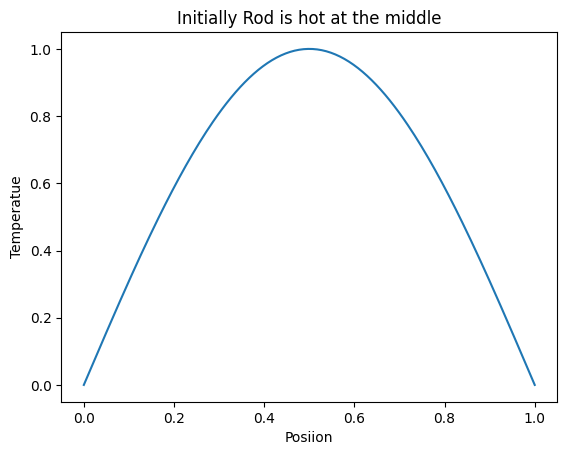

In [30]:
plt.plot(x_initial.cpu().numpy(), T_initial.cpu().numpy())
plt.title("Initially Rod is hot at the middle")
plt.xlabel("Posiion")
plt.ylabel("Temperatue")
plt.show()

# Boundary Condition Points

In [31]:
N_boundary=200

t_boundary=torch.linspace(
    0,T_max,N_boundary,device=device
).reshape(-1,1)

In [34]:
# left boundary x=0
x_left=torch.zeros_like(t_boundary)
#right boundary x=1
x_right=torch.ones_like(t_boundary)

# Training

In [36]:
epochs=5000
loss_history=[]

for epoch in range(epochs):

  optimizer.zero_grad()

  #forward pass
  T_physics=model(x_physics,t_physics)

  # calculate T_t (dT/dt)
  T_t=torch.autograd.grad(
      outputs=T_physics,
      inputs=t_physics,
      grad_outputs=torch.ones_like(T_physics),
      create_graph=True
  )[0]

  #calculate T_x
  T_x=torch.autograd.grad(
      outputs=T_physics,
      inputs=x_physics,
      grad_outputs=torch.ones_like(T_physics),
      create_graph=True
  )[0]

  #calculate T_Xx
  T_xx=torch.autograd.grad(
      outputs=T_x,
      inputs=x_physics,
      grad_outputs=torch.ones_like(T_x),
      create_graph=True
  )[0]

  #residual
  residual=T_t-alpha*T_xx

  #physics loss
  physics_loss=torch.mean(residual**2)

  # initial condintion loss
  T_initial_pred=model(x_initial,t_initial)

  ic_loss=torch.mean(
      (T_initial_pred-T_initial)**2
  )

  # Boundary Condition loss
  T_left=model(x_left,t_boundary)

  T_right=model(x_right,t_boundary)

  bc_loss =torch.mean(T_left**2)+torch.mean(T_right**2)

  #Total Loss
  total_loss=physics_loss+ic_loss+bc_loss

  #backpropagation
  total_loss.backward()

  #weight update
  optimizer.step()

  loss_history.append(total_loss.item())

  if epoch%300==0:
    print(f"Epoch:{epoch:5d}|phy_loss:{physics_loss.item():6e}|ic_loss:{ic_loss.item():6e}|bc_loss:{bc_loss.item():6e}|total_loss:{total_loss.item():6e}")

Epoch:    0|phy_loss:4.130680e-03|ic_loss:4.651981e-01|bc_loss:4.527555e-03|total_loss:4.738564e-01
Epoch:  300|phy_loss:9.322473e-04|ic_loss:2.102572e-04|bc_loss:4.775564e-04|total_loss:1.620061e-03
Epoch:  600|phy_loss:1.328976e-04|ic_loss:1.562363e-05|bc_loss:4.058176e-05|total_loss:1.891030e-04
Epoch:  900|phy_loss:7.109164e-05|ic_loss:9.061911e-06|bc_loss:2.771372e-05|total_loss:1.078673e-04
Epoch: 1200|phy_loss:6.494840e-05|ic_loss:1.496202e-04|bc_loss:2.899773e-04|total_loss:5.045459e-04
Epoch: 1500|phy_loss:4.534714e-05|ic_loss:3.519896e-06|bc_loss:1.662304e-05|total_loss:6.549008e-05
Epoch: 1800|phy_loss:3.949954e-05|ic_loss:1.291218e-05|bc_loss:4.300772e-05|total_loss:9.541943e-05
Epoch: 2100|phy_loss:3.298054e-05|ic_loss:2.718760e-06|bc_loss:1.301958e-05|total_loss:4.871888e-05
Epoch: 2400|phy_loss:2.866552e-05|ic_loss:1.988731e-06|bc_loss:7.715926e-06|total_loss:3.837017e-05
Epoch: 2700|phy_loss:2.549643e-05|ic_loss:4.589982e-06|bc_loss:1.161811e-05|total_loss:4.170452e-05


# Test points

In [54]:
N_test = 100

x_test = torch.linspace(
    0,
    L,
    N_test,
    device=device
).reshape(-1, 1)

t_test = torch.linspace(
    0,
    T_max,
    N_test,
    device=device
).reshape(-1, 1)


# Create meshgrid

X, TT = torch.meshgrid(
    x_test.squeeze(),
    t_test.squeeze(),
    indexing="ij"
)


X_flat = X.reshape(-1, 1)
T_flat = TT.reshape(-1, 1)


#PINN Prediction

In [55]:
with torch.no_grad():

    T_pinn = model(
        X_flat,
        T_flat
    )


T_pinn = T_pinn.reshape(
    N_test,
    N_test
)

# Exact ANalytical Solution

In [56]:
T_exact = (
    torch.exp(
        -alpha
        * torch.pi**2
        * TT
    )
    *
    torch.sin(
        torch.pi * X
    )
)

In [58]:
relative_error = (
    torch.linalg.norm(
        T_pinn - T_exact
    )
    /
    torch.linalg.norm(
        T_exact
    )
)


print("\nRelative L2 Error:",relative_error.item())


Relative L2 Error: 0.000978516531176865


#loss curve

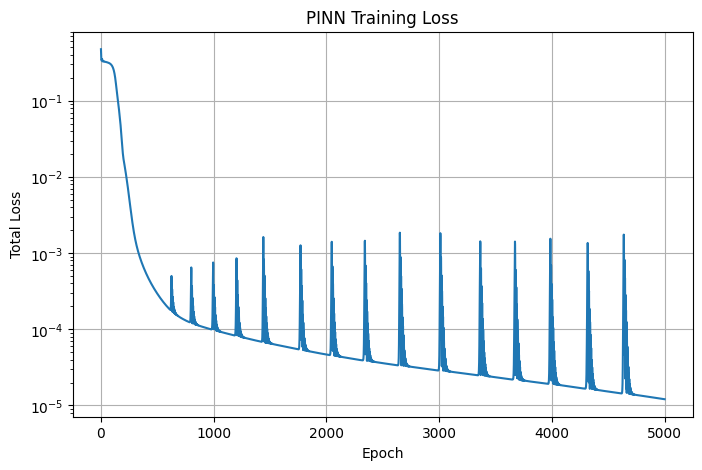

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Total Loss")

plt.title("PINN Training Loss")

plt.grid()

plt.show()

#PINN Solution

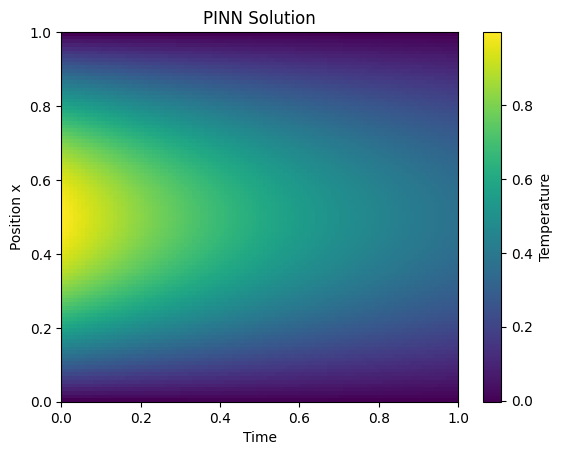

In [61]:
plt.imshow(
    T_pinn.cpu().numpy(),
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Temperature")

plt.xlabel("Time")
plt.ylabel("Position x")

plt.title("PINN Solution")

plt.show()

#Exact Solution

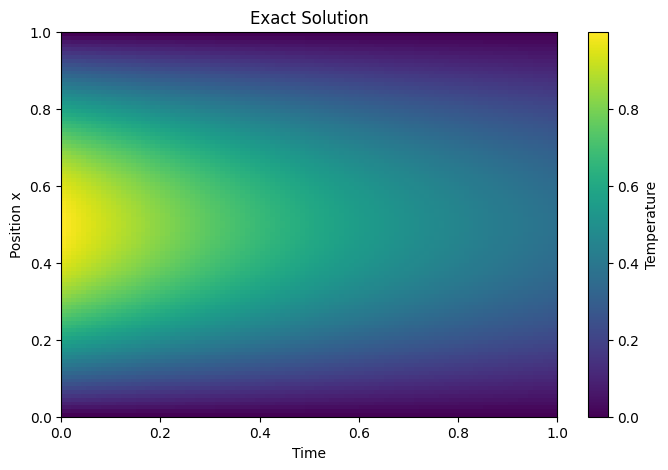

In [62]:
plt.figure(figsize=(8, 5))

plt.imshow(
    T_exact.cpu().numpy(),
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Temperature")

plt.xlabel("Time")
plt.ylabel("Position x")

plt.title("Exact Solution")

plt.show()

#error map

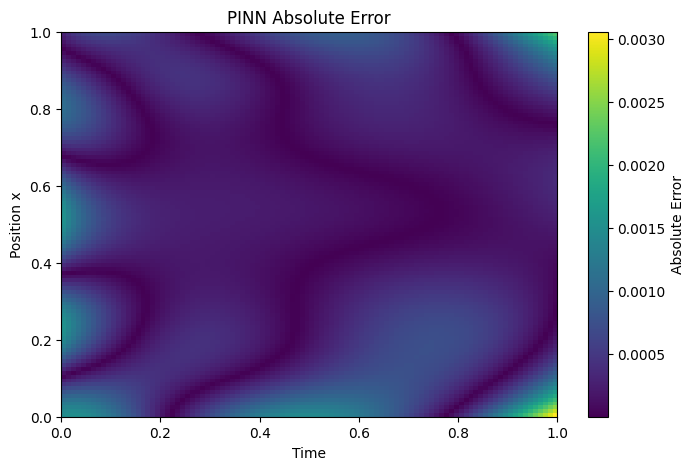

In [63]:
error = torch.abs(
    T_pinn - T_exact
)


plt.figure(figsize=(8, 5))

plt.imshow(
    error.cpu().numpy(),
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Absolute Error")

plt.xlabel("Time")
plt.ylabel("Position x")

plt.title("PINN Absolute Error")

plt.show()

# Fix position At x=0.5 PINN and exact Solution Graph

In [64]:
N_test=100

t_test=torch.linspace(
    0,T_max,N_test,device=device
).reshape(-1,1)


In [67]:
# fixed position at x=0.5
x_test=torch.full_like(t_test,0.5)
x_test.shape ,t_test.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [69]:
#pinn
with torch.no_grad():
  T_pinn=model(x_test,t_test)

In [70]:
#exact solution
T_exact=torch.exp(-alpha*torch.pi**2*t_test)*torch.sin(torch.pi * x_test)

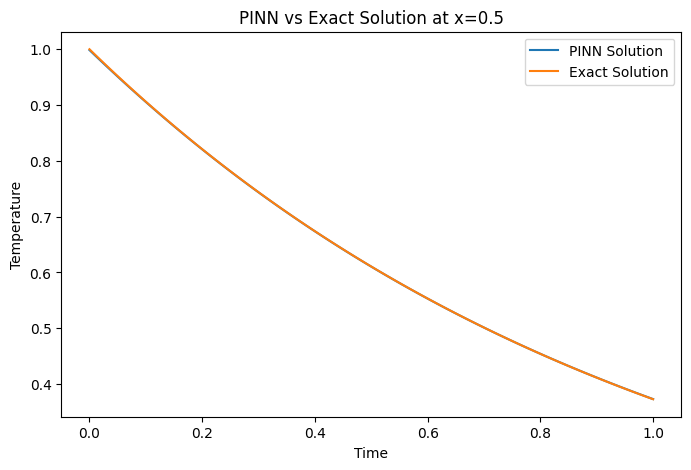

In [73]:
plt.figure(figsize=(8,5))
plt.plot(t_test.cpu().numpy(),T_pinn.cpu().numpy(),
         label="PINN Solution")

plt.plot(t_test.cpu().numpy(),T_exact.cpu().numpy(),
         label="Exact Solution")

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("PINN vs Exact Solution at x=0.5")
plt.legend()
plt.show()

#Fix Time at time=0.2

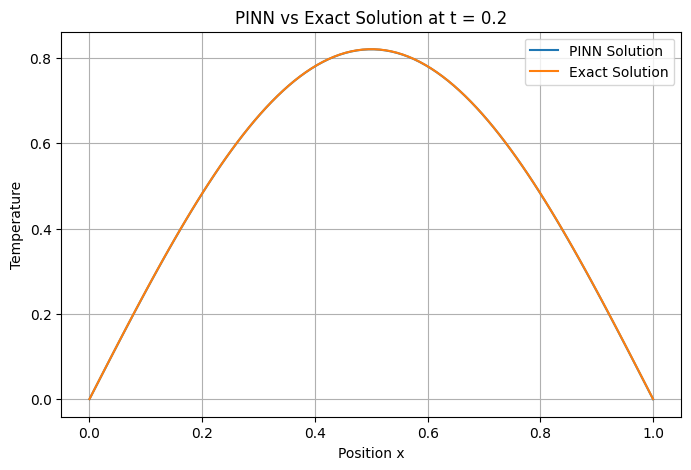

In [74]:
N_test = 100

x_test = torch.linspace(
    0,
    L,
    N_test,
    device=device
).reshape(-1, 1)


# Fix time
t_test = torch.full_like(
    x_test,
    0.2
)


# PINN prediction
with torch.no_grad():

    T_pinn = model(
        x_test,
        t_test
    )


# Exact solution
T_exact = (
    torch.exp(
        -alpha
        * torch.pi**2
        * t_test
    )
    *
    torch.sin(
        torch.pi * x_test
    )
)


# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    x_test.cpu().numpy(),
    T_pinn.cpu().numpy(),
    label="PINN Solution"
)

plt.plot(
    x_test.cpu().numpy(),
    T_exact.cpu().numpy(),
    label="Exact Solution"
)

plt.xlabel("Position x")
plt.ylabel("Temperature")

plt.title(
    "PINN vs Exact Solution at t = 0.2"
)

plt.legend()

plt.grid()

plt.show()